## Helpers & import

In [2]:
import os, pickle, sys
import numpy as np
import torch
import torch.nn as nn
from scipy.optimize import curve_fit
from IPython.display import clear_output
import pandas as pd
from stable_baselines3 import DQN
from stable_baselines3.common.buffers import ReplayBuffer
from stable_baselines3.common.utils import configure_logger
import matplotlib.pyplot as plt

In [3]:
bounds = {
    "T_in": (273,324),
    "T_out": (257,305),
    "Psol": (0, 862),
}

In [4]:
kelvin = lambda c: c + 273.15
celc = lambda k: k -273.15

In [5]:
def denormalize_df(df, bounds):
    #De-normalization of DataFrame columns from [-1, 1]
    for col, (x_min, x_max) in bounds.items():
        df[col] = 0.5 * (df[col] + 1.0) * (x_max - x_min) + x_min

def normalize_df(df, bounds):
    #normalizer of Dataframe columns to [-1, 1]
    for col, (x_min, x_max) in bounds.items():
        df[col] = 2.0 * (df[col] - x_min) / (x_max - x_min) - 1.0

In [6]:
#normalizer / denormalizer for single values
def denormalize(norm_vals, lo, hi): 
    return 0.5 * (norm_vals + 1.0) * (hi - lo) + lo

def normalize(raw_vals, lo, hi):
    return 2.0 * (raw_vals - lo) / (hi - lo) - 1.0

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device}")

Using cuda


In [8]:
heater_power = 15000.0   #15 kWh
step_period_s = 1800.0
step_period_h = 0.5

## RC

In [10]:
class RCModel:
    def __init__(self):
        self.Ri = 9.00e-5 #taken from apendix for start but is still fitted
        self.Re = 3.20e-3
        self.Ci = 6.49e7
        self.Ce = 7.78e8
        self.Ai = 28.94
        self.Ae = 0.00066

    def step(self, T_in, T_e, T_out, Phi_h, Phi_s, dt=1800.0): #should be eq 4 but needs to be checked
        dT_in = (-(1/(self.Ri*self.Ci))*T_in
                  +(1/(self.Ri*self.Ci))*T_e
                  +(1/self.Ci)*Phi_h
                  +(self.Ai/self.Ci)*Phi_s)
        dT_e  = ( (1/(self.Ri*self.Ce))*T_in
                 -(1/(self.Ri*self.Ce)+1/(self.Re*self.Ce))*T_e
                  +(1/(self.Re*self.Ce))*T_out
                  +(self.Ae/self.Ce)*Phi_s)
        return T_in + dT_in*dt, T_e + dT_e*dt

    def predict_T_in_next(self, T_in, T_e, T_out, Phi_h, Phi_s, dt=1800.0):
        T_in_next, _ = self.step(T_in, T_e, T_out, Phi_h, Phi_s, dt)
        return T_in_next

    def fit(self, T_in, T_out, Phi_h, Phi_s, T_in_next, dt=1800.0):
        T_e_est = T_in - 1.0 

        def _predict(X, Ri, Re, Ci, Ce, Ai, Ae):
            _T_in, _T_e, _T_out, _Phi_h, _Phi_s = X
            dT_in = (-(1/(Ri*Ci))*_T_in + (1/(Ri*Ci))*_T_e
                      +(1/Ci)*_Phi_h + (Ai/Ci)*_Phi_s)
            return _T_in + dT_in*dt

        X = (T_in, T_e_est, T_out, Phi_h, Phi_s)
        p0     = [self.Ri, self.Re, self.Ci, self.Ce, self.Ai, self.Ae]
        bounds = ([1e-8]*6, [np.inf]*6)
        try:
            popt, _ = curve_fit(_predict, X, T_in_next,
                                p0=p0, bounds=bounds, maxfev=20000)
            self.Ri, self.Re, self.Ci, self.Ce, self.Ai, self.Ae = popt
            print(f"RC fit OK — Ri={self.Ri:.2e} Re={self.Re:.2e} "
                  f"Ci={self.Ci:.2e} Ce={self.Ce:.2e} "
                  f"Ai={self.Ai:.2f} Ae={self.Ae:.5f}")
        except RuntimeError as e:
            print(f"RC fit did not converge ({e}). Using paper values.")

## PINN

In [12]:
class PINN(nn.Module): #TODO check if we want to add price??? the paper has 17 inputs with a constant price
    def __init__(self, input_dim=16):
        super().__init__()
        self.fc1      = nn.Linear(input_dim, 32)
        self.fc2      = nn.Linear(32, 32)
        self.norm     = nn.LayerNorm(32)
        self.relu     = nn.ReLU()
        self.out      = nn.Linear(32, 1)
        self.log_lambda = nn.Parameter(torch.tensor(0.0))

    @property
    def lam(self):
        return torch.exp(self.log_lambda)

    def forward(self, x):
        x = self.relu(self.norm(self.fc1(x)))
        x = self.relu(self.fc2(x))
        return self.out(x).squeeze(-1)

    def compute_loss(self, x, T_in_actual_norm, T_in_rc_norm):
        T_in_nn = self.forward(x)
        mse_nn  = torch.mean((T_in_nn - T_in_actual_norm) ** 2)  # Eq. 2
        mse_rc  = torch.mean((T_in_rc_norm - T_in_nn) ** 2)      # Eq. 3
        total   = mse_nn + self.lam * mse_rc                     # Eq. 1
        return total, mse_nn.item(), mse_rc.item()

## NN

In [14]:
class NN(nn.Module):
    def __init__(self, input_dim=16):
        super().__init__()
        self.fc1      = nn.Linear(input_dim, 128)
        self.fc2      = nn.Linear(128, 128)
        self.norm     = nn.LayerNorm(128)
        self.relu     = nn.ReLU()
        self.out      = nn.Linear(128, 1)

    def forward(self, x):
        x = self.relu(self.norm(self.fc1(x)))
        x = self.relu(self.fc2(x))
        return self.out(x).squeeze(-1)

    def compute_loss(self, x, T_in_actual_norm):
        T_in_nn = self.forward(x)
        return torch.mean((T_in_nn - T_in_actual_norm) ** 2)

## Boptest env creation

In [16]:
import sys, requests, csv, datetime
sys.path.insert(0, '../boptestGym')
from boptestGymEnv import BoptestGymEnv, NormalizedObservationWrapper, DiscretizedActionWrapper

url = "http://localhost:80"

class BoptestGymEnvCustomReward(BoptestGymEnv):
    def get_reward(self):
        kpis = requests.get('{0}/kpi/{1}'.format(self.url, self.testid)).json()['payload']
        reward = -((kpis['tdis_tot'] * 1.0) + (kpis['ener_tot'] * 1.0))
        self.objective_integrand = reward
        return reward
        
def create_env(max_start):
    env = BoptestGymEnvCustomReward(url       = url,
                    testcase              = 'bestest_hydronic_heat_pump',
                    actions               = ['oveHeaPumY_u'],
                    observations          = {'reaTZon_y':(273.,324.), #0 / 50
                                             'weaSta_reaWeaTDryBul_y':(257.,305.), # -15 / 28.8
                                             'weaSta_reaWeaHDirNor_y':(0.,862.)
                                            },
                    random_start_time     = True,
                    max_episode_length    = 7 * 24*3600,
                    excluding_periods     = [(max_start, 365*24*3600)],
                    warmup_period         = 24*3600,
                    predictive_period     = 0,
                    regressive_period     = 4*1800,
                    step_period           = 1800
                               )
    env = NormalizedObservationWrapper(env)
    env = DiscretizedActionWrapper(env, n_bins_act=1)
    return env

## Planning

In [18]:
low_setpoint_k  = kelvin(21.0)
high_setpoint_k = kelvin(24.0)
floor_area = 16 * 12 #from the testcase page
planning_epsilon = 0.3

def compute_reward_from_norm_T_in(T_in_norm, action):
    T_in_K_val = denormalize(T_in_norm, *bounds["T_in"])
    discomfort = (max(0.0, low_setpoint_k  - T_in_K_val) +
                  max(0.0, T_in_K_val - high_setpoint_k)) * step_period_h
    energy = float(action) * 15.0 * step_period_h  / floor_area
    return -(discomfort + energy)


def get_new_obs(obs_15, new_T_in_norm, new_T_out_norm=None, new_P_sol_norm=None):
    next_obs = obs_15.copy()
    # T_in lags
    next_obs[6] = next_obs[5]
    next_obs[5] = next_obs[4]
    next_obs[4] = next_obs[3]
    next_obs[3] = next_obs[0]
    next_obs[0] = new_T_in_norm

    t_out_new = new_T_out_norm if new_T_out_norm is not None else next_obs[1]
    next_obs[10] = next_obs[9]
    next_obs[9]  = next_obs[8]
    next_obs[8]  = next_obs[7]
    next_obs[7]  = next_obs[1]
    next_obs[1]  = t_out_new

    psol_new = new_P_sol_norm if new_P_sol_norm is not None else next_obs[2]
    next_obs[14] = next_obs[13]
    next_obs[13] = next_obs[12]
    next_obs[12] = next_obs[11]
    next_obs[11] = next_obs[2]
    next_obs[2]  = psol_new
    return next_obs

## DYNA-PINN

In [20]:
def run_dyna_pinn_episode(
    model,              # SB3 DQ
    pinn,               # trained PINN (updated in-place)
    rc,                 # RCModel
    sim_buffer,         #simulated buffer created by pinn
    planning_steps,     # 50 or 100
    EPOCHS=50,
    n_start_states=64,
):

    # directly starts from pinn training since the phase 1 of paper is the other baseline code for ex DNQ_switch
    buf = model.replay_buffer
    n   = buf.pos if not buf.full else buf.buffer_size

    obs_n      = buf.observations[:n].reshape(n, -1).astype(np.float32)
    next_obs_n = buf.next_observations[:n].reshape(n, -1).astype(np.float32)
    acts       = buf.actions[:n].reshape(n).astype(np.float32)

    T_in_c      = celc(denormalize(obs_n[:, 0], *bounds["T_in"]))
    T_out_c     = celc(denormalize(obs_n[:, 1], *bounds["T_out"]))
    Psol        = denormalize(obs_n[:, 2], *bounds["Psol"])
    phi_h       = (acts == 1).astype(np.float32) * heater_power
    T_e_est     = T_in_c - 1.0
    T_rc_c, _   = rc.step(T_in_c, T_e_est, T_out_c, phi_h, Psol, step_period_s)
    T_rc_norm   = normalize(kelvin(T_rc_c), *bounds["T_in"]).astype(np.float32)
    T_next_norm = next_obs_n[:, 0]
    X           = np.hstack([obs_n, acts.reshape(-1, 1)])
    
    pinn.train()
    for _ in range(EPOCHS):
        idx   = np.random.choice(n, BATCH, replace=False)
        xb    = torch.tensor(X[idx],          device=device)
        ya    = torch.tensor(T_next_norm[idx], device=device)
        yrc   = torch.tensor(T_rc_norm[idx],   device=device)
        optimizer_pinn.zero_grad()
        loss, _, _ = pinn.compute_loss(xb, ya, yrc)
        loss.backward()
        optimizer_pinn.step()
    
    pinn.eval()
    start_idx_arr = np.random.choice(n, n_start_states, replace=False)
    with torch.no_grad():
        for si in start_idx_arr:
            cur_obs = obs_n[si].copy()
            for _ in range(planning_steps):
                obs_t  = torch.tensor(cur_obs, device=device).unsqueeze(0)
                if np.random.random() < planning_epsilon:
                    action = np.random.randint(0, 2)
                else:
                    action = model.policy.q_net(obs_t).argmax(dim=1).item()
                x_p    = torch.tensor(
                    np.append(cur_obs, float(action)),
                    dtype=torch.float32, device=device
                ).unsqueeze(0)
                t_next_n = float(np.clip(pinn(x_p).item(), -1.0, 1.0))
                nxt_obs  = get_new_obs(cur_obs, t_next_n)
                rew      = compute_reward_from_norm_T_in(t_next_n, action)
                sim_buffer.add(
                    obs=cur_obs.reshape(1,-1), next_obs=nxt_obs.reshape(1,-1),
                    action=np.array([[action]]), reward=np.array([rew]),
                    done=np.array([False]), infos=[{}]
                )
                cur_obs = nxt_obs
    pinn.train()

    # model retrained on both real and simulated experience
    for step in range(planning_steps * n_start_states):
        if step % 2 == 0:
            model.train(gradient_steps=1, batch_size=64)
        else:
            sim_data  = sim_buffer.sample(64)
            with torch.no_grad():
                next_q   = model.policy.q_net_target(sim_data.next_observations).max(dim=1).values
                target_q = sim_data.rewards.squeeze() + 0.99 * next_q * (1 - sim_data.dones.squeeze().float())
            current_q = model.policy.q_net(sim_data.observations).gather(
                            1, sim_data.actions.long()).squeeze()
            loss = nn.functional.mse_loss(current_q, target_q)
            model.policy.optimizer.zero_grad()
            loss.backward()
            model.policy.optimizer.step()

## NN DDQ

In [22]:
def run_ddq_nn_episode(
    model,              # SB3 DQ
    nn_model,               # trained PINN (updated in-place)
    sim_buffer,         #simulated buffer created by pinn
    planning_steps,     # 50 or 100
    EPOCHS=50,
    n_start_states=64,
):

    # directly starts from pinn training since the phase 1 of paper is the other baseline code for ex DNQ_switch
    buf = model.replay_buffer
    n   = buf.pos if not buf.full else buf.buffer_size

    obs_n      = buf.observations[:n].reshape(n, -1).astype(np.float32)
    next_obs_n = buf.next_observations[:n].reshape(n, -1).astype(np.float32)
    acts       = buf.actions[:n].reshape(n).astype(np.float32)

    T_in_c      = celc(denormalize(obs_n[:, 0], *bounds["T_in"]))
    T_out_c     = celc(denormalize(obs_n[:, 1], *bounds["T_out"]))
    Psol        = denormalize(obs_n[:, 2], *bounds["Psol"])
    T_e_est     = T_in_c - 1.0
    T_next_norm = next_obs_n[:, 0]
    X           = np.hstack([obs_n, acts.reshape(-1, 1)])
    
    nn_model.train()
    for _ in range(EPOCHS):
        idx   = np.random.choice(n, BATCH, replace=False)
        xb    = torch.tensor(X[idx],          device=device)
        ya    = torch.tensor(T_next_norm[idx], device=device)
        optimizer_nn.zero_grad()
        loss = nn_model.compute_loss(xb, ya)
        loss.backward()
        optimizer_nn.step()

    nn_model.eval()
    start_idx_arr = np.random.choice(n, n_start_states, replace=False)
    with torch.no_grad():
        for si in start_idx_arr:
            cur_obs = obs_n[si].copy()
            for _ in range(planning_steps):
                obs_t  = torch.tensor(cur_obs, device=device).unsqueeze(0)
                if np.random.random() < planning_epsilon:
                    action = np.random.randint(0, 2)
                else:
                    action = model.policy.q_net(obs_t).argmax(dim=1).item()
                x_p    = torch.tensor(
                    np.append(cur_obs, float(action)),
                    dtype=torch.float32, device=device
                ).unsqueeze(0)
                t_next_n = float(np.clip(nn_model(x_p).item(), -1.0, 1.0))
                nxt_obs  = get_new_obs(cur_obs, t_next_n)
                rew      = compute_reward_from_norm_T_in(t_next_n, action)
                sim_buffer.add(
                    obs=cur_obs.reshape(1,-1), next_obs=nxt_obs.reshape(1,-1),
                    action=np.array([[action]]), reward=np.array([rew]),
                    done=np.array([False]), infos=[{}]
                )
                cur_obs = nxt_obs
    nn_model.train()

    # model retrained on both real and simulated experience
    for step in range(planning_steps * n_start_states):
        if step % 2 == 0:
            model.train(gradient_steps=1, batch_size=64)
        else:
            sim_data  = sim_buffer_nn.sample(64)
            with torch.no_grad():
                next_q   = model.policy.q_net_target(sim_data.next_observations).max(dim=1).values
                target_q = sim_data.rewards.squeeze() + 0.99 * next_q * (1 - sim_data.dones.squeeze().float())
            current_q = model.policy.q_net(sim_data.observations).gather(
                            1, sim_data.actions.long()).squeeze()
            loss = nn.functional.mse_loss(current_q, target_q)
            model.policy.optimizer.zero_grad()
            loss.backward()
            model.policy.optimizer.step()

## RC DDQ

In [24]:
def run_rc_ddq_episode(
    model,              # SB3 DQ
    planning_steps,     # 50 or 100
    sim_buffer,
    n_start_states=64,
):

    buf = model.replay_buffer
    n   = buf.pos if not buf.full else buf.buffer_size

    obs_n      = buf.observations[:n].reshape(n, -1).astype(np.float32)
    next_obs_n = buf.next_observations[:n].reshape(n, -1).astype(np.float32)
    acts       = buf.actions[:n].reshape(n).astype(np.float32)
    
    start_idx_arr = np.random.choice(n, n_start_states, replace=False)
    with torch.no_grad():
        for si in start_idx_arr:
            cur_obs = obs_n[si].copy()
            for _ in range(planning_steps):
                obs_t  = torch.tensor(cur_obs, device=device).unsqueeze(0)
                if np.random.random() < planning_epsilon:
                    action = np.random.randint(0, 2)
                else:
                    action = model.policy.q_net(obs_t).argmax(dim=1).item()
                T_in_c  = celc(denormalize(cur_obs[0], *bounds["T_in"]))
                T_out_c = celc(denormalize(cur_obs[1], *bounds["T_out"]))
                Psol    = denormalize(cur_obs[2], *bounds["Psol"])
                Phi_h   = float(action) * heater_power
                T_in_rc_next, _ = rc.step(
                    np.array([T_in_c]), np.array([T_in_c - 1.0]),
                    np.array([T_out_c]), np.array([Phi_h]),
                    np.array([Psol]), step_period_s
                )
                t_next_n = float(np.clip(
                    normalize(kelvin(float(T_in_rc_next[0])), *bounds["T_in"]), -1.0, 1.0
                ))
                nxt_obs  = get_new_obs(cur_obs, t_next_n)
                rew      = compute_reward_from_norm_T_in(t_next_n, action)
                sim_buffer.add(
                    obs=cur_obs.reshape(1,-1), next_obs=nxt_obs.reshape(1,-1),
                    action=np.array([[action]]), reward=np.array([rew]),
                    done=np.array([False]), infos=[{}]\
                )
                cur_obs = nxt_obs

    # model retrained on both real and simulated experience
    for step in range(planning_steps * n_start_states):
        if step % 2 == 0:
            model.train(gradient_steps=1, batch_size=64)
        else:
            sim_data  = sim_buffer.sample(64)
            with torch.no_grad():
                next_q   = model.policy.q_net_target(sim_data.next_observations).max(dim=1).values
                target_q = sim_data.rewards.squeeze() + 0.99 * next_q * (1 - sim_data.dones.squeeze().float())
            current_q = model.policy.q_net(sim_data.observations).gather(
                            1, sim_data.actions.long()).squeeze()
            loss = nn.functional.mse_loss(current_q, target_q)
            model.policy.optimizer.zero_grad()
            loss.backward()
            model.policy.optimizer.step()

## Training loop for all models

In [26]:
PINN_LR           = 0.0091
PINN_WEIGHT_DECAY = 1.05e-5
NN_LR             = 0.0011
NN_WEIGHT_DECAY   = 2.38e-4
EPOCHS       = 50
BATCH        = 64
N_START_STATES = 64
episode_length = 7   * 24 * 3600
feb15 = 47 * 24*3600                    # Jan 1 → Feb 15 low data regime
june30 = 181 * 24 *3600 

log_path = os.path.join("Logs")

In [27]:
for data_regime in [27]:
    for training_episodes in [25, 50]:
        for planning_steps in [50, 100]:

            #load memory buffer
            buffer_log = f"Memory Buffers/DQN_switch_1_{data_regime}_{training_episodes}.pkl"
            with open(buffer_log, "rb") as f:
                buf = pickle.load(f)

            n_valid = buf.pos if not buf.full else buf.buffer_size

            obs_norm      = buf.observations[:n_valid].reshape(n_valid, -1)
            next_obs_norm = buf.next_observations[:n_valid].reshape(n_valid, -1)
            actions       = buf.actions[:n_valid].reshape(n_valid)
            rewards       = buf.rewards[:n_valid].reshape(n_valid)
            dones = buf.dones[:n_valid].reshape(n_valid).astype(bool)
            df = pd.DataFrame({
                "T_in":  obs_norm[:, 0],
                "T_out": obs_norm[:, 1],
                "Psol": obs_norm[:, 2],
            })

            denormalize_df(df, bounds)

            T_in_C  = celc(df["T_in"].values)
            T_out_C = celc(df["T_out"].values)
            Psol   = df["Psol"].values

            T_in_next_C = celc(denormalize(next_obs_norm[:, 0], *bounds["T_in"]))
            Phi_h = (actions == 1).astype(np.float32) * heater_power # Heat pump power

            rc = RCModel()
            rc.fit(T_in_C, T_out_C, Phi_h, Psol, T_in_next_C)
            
            #train pinn and nn on the buffer 
            T_e_est_C = T_in_C - 1.0
            T_in_rc_C, _ = rc.step(T_in_C, T_e_est_C, T_out_C, Phi_h, Psol, step_period_s)

            T_in_rc_norm = normalize(kelvin(T_in_rc_C), *bounds["T_in"]).astype(np.float32)

            T_in_next_norm = next_obs_norm[:, 0].astype(np.float32)

            X_all = np.hstack([
                obs_norm.astype(np.float32),
                actions.reshape(-1, 1).astype(np.float32)
            ])  # (N, 16)
            
            model_path = f"Saved Models/DQN_switch_1_{data_regime}_{training_episodes}"
            print(f"training episode: {training_episodes}")
            if data_regime == 6:
                max_start = feb15 - episode_length      # last valid start time
                print("6 weeks")
            elif data_regime == 27:
                max_start = june30 - episode_length      # last valid start time
                print("27 weeks")
            env = create_env(max_start)

            sim_buffer    = ReplayBuffer(planning_steps * N_START_STATES * training_episodes, env.observation_space, env.action_space, device=device)
            sim_buffer_nn = ReplayBuffer(planning_steps * N_START_STATES * training_episodes, env.observation_space, env.action_space, device=device)
            sim_buffer_rc = ReplayBuffer(planning_steps * N_START_STATES * training_episodes, env.observation_space, env.action_space, device=device)
    
            model_pinn = DQN.load(model_path, env=env, device=device)
            model_nn   = DQN.load(model_path, env=env, device=device)
            model_rc   = DQN.load(model_path, env=env, device=device)    
            model_pinn.load_replay_buffer(buffer_log)
            model_nn.load_replay_buffer(buffer_log)
            model_rc.load_replay_buffer(buffer_log)
            model_pinn.set_logger(configure_logger(0, None, "", False))
            model_nn.set_logger(configure_logger(0, None, "", False))
            model_rc.set_logger(configure_logger(0, None, "", False))

            pinn     = PINN(input_dim=16).to(device)
            nn_model = NN(input_dim=16).to(device)
            optimizer_pinn = torch.optim.Adam(pinn.parameters(),     lr=PINN_LR, weight_decay=PINN_WEIGHT_DECAY)
            optimizer_nn   = torch.optim.Adam(nn_model.parameters(), lr=NN_LR,   weight_decay=NN_WEIGHT_DECAY)

            for epoch in range(EPOCHS):
                idx  = np.random.choice(len(X_all), BATCH, replace=False)
                xb   = torch.tensor(X_all[idx], device=device)
                ya   = torch.tensor(T_in_next_norm[idx], device=device)
                yrc  = torch.tensor(T_in_rc_norm[idx], device=device)
                optimizer_pinn.zero_grad()
                loss, _, _ = pinn.compute_loss(xb, ya, yrc)
                loss.backward()
                optimizer_pinn.step()

                optimizer_nn.zero_grad()
                loss_nn = nn_model.compute_loss(xb, ya)
                loss_nn.backward()
                optimizer_nn.step()
    
            # train PINN variant
            for ep in range(1, training_episodes + 1):
                run_dyna_pinn_episode(model_pinn, pinn, rc, sim_buffer, planning_steps=planning_steps, EPOCHS=EPOCHS, n_start_states=N_START_STATES)
            model_pinn.save(f"Saved Models/DynaPINN_{data_regime}_{training_episodes}_{planning_steps}steps")

            # train NN variant
            for ep in range(1, training_episodes + 1):
                run_ddq_nn_episode(model_nn, nn_model, sim_buffer_nn, planning_steps=planning_steps, EPOCHS=EPOCHS, n_start_states=N_START_STATES)
            model_nn.save(f"Saved Models/DynaNN_{data_regime}_{training_episodes}_{planning_steps}steps")

            # train RC variant
            for ep in range(1, training_episodes + 1):
                run_rc_ddq_episode(model_rc, planning_steps=planning_steps, sim_buffer=sim_buffer_rc, n_start_states=N_START_STATES)
            model_rc.save(f"Saved Models/DynaRC_{data_regime}_{training_episodes}_{planning_steps}steps")

            env.stop()
            del model_pinn, model_nn, model_rc
            sim_buffer.pos = 0
            sim_buffer_nn.pos = 0
            sim_buffer_rc.pos = 0

print("\nAll variants trained and saved.")

RC fit OK — Ri=1.84e-04 Re=3.90e+09 Ci=9.39e+07 Ce=7.78e+08 Ai=27.17 Ae=0.00066
training episode: 25
27 weeks


C:\Users\irmak\anaconda3\Lib\site-packages\gymnasium\spaces\box.py:130: UserWarning: WARN: Box bound precision lowered by casting to float32
  gym.logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
RC fit OK — Ri=1.84e-04 Re=3.90e+09 Ci=9.39e+07 Ce=7.78e+08 Ai=27.17 Ae=0.00066
training episode: 25
27 weeks


C:\Users\irmak\anaconda3\Lib\site-packages\gymnasium\spaces\box.py:130: UserWarning: WARN: Box bound precision lowered by casting to float32
  gym.logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
RC fit OK — Ri=1.97e-04 Re=6.52e+08 Ci=1.22e+08 Ce=7.78e+08 Ai=32.89 Ae=0.00066
training episode: 50
27 weeks
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
RC fit OK — Ri=1.97e-04 Re=6.52e+08 Ci=1.22e+08 Ce=7.78e+08 Ai=32.89 Ae=0.00066
training episode: 50
27 weeks
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.

All variants trained and saved.


In [28]:
env.stop()

# run once

## Replay buffer load

## 5. Train PINN / NN on the real buffer

## PINN prediction vs RC vs actual

MAE (PINN vs actual): 0.3408 °C
MAE (RC   vs actual): 0.0980 °C


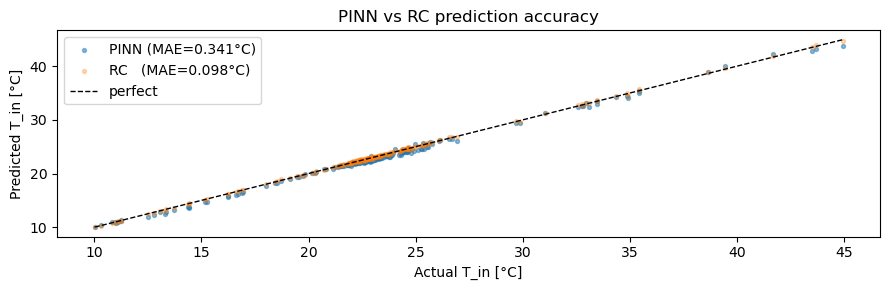

In [33]:
pinn.eval()
sample_idx = np.random.choice(n_valid, 200, replace=False)

x_check = torch.tensor(X_all[sample_idx], device=device)
with torch.no_grad():
    pinn_pred_norm = pinn(x_check).cpu().numpy()

actual_norm = T_in_next_norm[sample_idx]
rc_pred_norm = T_in_rc_norm[sample_idx]

def to_celsius(norm_arr):
    return celc(denormalize(norm_arr, *bounds["T_in"]))

mae_pinn = np.mean(np.abs(to_celsius(pinn_pred_norm) - to_celsius(actual_norm)))
mae_rc   = np.mean(np.abs(to_celsius(rc_pred_norm)   - to_celsius(actual_norm)))

print(f"MAE (PINN vs actual): {mae_pinn:.4f} °C")
print(f"MAE (RC   vs actual): {mae_rc:.4f} °C")

plt.figure(figsize=(9, 3))
plt.scatter(to_celsius(actual_norm), to_celsius(pinn_pred_norm),
            s=8, alpha=0.5, label=f"PINN (MAE={mae_pinn:.3f}°C)")
plt.scatter(to_celsius(actual_norm), to_celsius(rc_pred_norm),
            s=8, alpha=0.3, label=f"RC   (MAE={mae_rc:.3f}°C)")
lo = to_celsius(actual_norm).min()
hi = to_celsius(actual_norm).max()
plt.plot([lo, hi], [lo, hi], 'k--', lw=1, label="perfect")
plt.xlabel("Actual T_in [°C]")
plt.ylabel("Predicted T_in [°C]")
plt.title("PINN vs RC prediction accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── 1. Save the trained PINN ─────────────────────────────────────
torch.save(pinn.state_dict(), "local_files/pinn_model_6_50_100.pt")
print("PINN saved to local_files/pinn_model_6_50_100.pt")

def evaluate_multistep_mae(
    pinn, nn_model, rc, X_all, obs_norm, next_obs_norm,
    T_in_rc_norm, T_in_next_norm,
    max_steps=100, n_episodes=50
):

    pinn.eval()
    nn_model.eval()
    mae_pinn_per_step = [[] for _ in range(max_steps)]
    mae_rc_per_step   = [[] for _ in range(max_steps)]
    mae_nn_per_step   = [[] for _ in range(max_steps)]
    raw_pinn_per_step = [[] for _ in range(max_steps)]
    raw_rc_per_step   = [[] for _ in range(max_steps)]
    raw_nn_per_step   = [[] for _ in range(max_steps)]

    # Sample starting states
    start_indices = np.random.choice(
        n_valid - max_steps, n_episodes, replace=False
    )

    with torch.no_grad():
        for start_idx in start_indices:
            cur_obs_pinn = obs_norm[start_idx].copy().astype(np.float32)
            cur_obs_nn   = obs_norm[start_idx].copy().astype(np.float32)
            T_e_rc       = T_in_C[start_idx] - 1.0   # RC envelope estimate
            cur_T_in_rc  = T_in_C[start_idx]

            for step in range(max_steps):
                actual_idx = start_idx + step + 1
                if actual_idx >= n_valid:
                    break

                # Actual next T_in in Celsius
                actual_T_in_C = to_celsius(T_in_next_norm[actual_idx - 1])

                #PINN prediction
                obs_t  = torch.tensor(cur_obs_pinn, device=device).unsqueeze(0)
                action = model_pinn.policy.q_net(obs_t).argmax(dim=1).item()
                x_pinn = torch.tensor(
                    np.append(cur_obs_pinn, float(action)),
                    dtype=torch.float32, device=device
                ).unsqueeze(0)
                T_in_pinn_norm = float(np.clip(pinn(x_pinn).item(), -1.0, 1.0))
                T_in_pinn_C    = to_celsius(T_in_pinn_norm)

                mae_pinn_per_step[step].append(abs(T_in_pinn_C - actual_T_in_C))
                raw_pinn_per_step[step].append(T_in_pinn_C - actual_T_in_C)
                cur_obs_pinn = get_new_obs(cur_obs_pinn, T_in_pinn_norm)

                # NN prediction
                x_nn = torch.tensor(
                    np.append(cur_obs_nn, float(action)),
                    dtype=torch.float32, device=device
                ).unsqueeze(0)
                T_in_nn_norm = float(np.clip(nn_model(x_nn).item(), -1.0, 1.0))
                mae_nn_per_step[step].append(abs(to_celsius(T_in_nn_norm) - actual_T_in_C))
                raw_nn_per_step[step].append(to_celsius(T_in_nn_norm) - actual_T_in_C)
                cur_obs_nn = get_new_obs(cur_obs_nn, T_in_nn_norm)
                
                # RC prediction
                T_out_step = celc(denormalize(
                    obs_norm[actual_idx - 1, 1], *bounds["T_out"]
                ))
                Psol_step  = denormalize(obs_norm[actual_idx - 1, 2], *bounds["Psol"])
                Phi_h_step = float(action) * heater_power

                T_in_rc_next, T_e_rc = rc.step(
                    np.array([cur_T_in_rc]),
                    np.array([T_e_rc]),
                    np.array([T_out_step]),
                    np.array([Phi_h_step]),
                    np.array([Psol_step]),
                    step_period_s
                )
                T_in_rc_C_pred = float(T_in_rc_next[0])
                T_e_rc         = float(T_e_rc[0])
                cur_T_in_rc    = T_in_rc_C_pred

                mae_rc_per_step[step].append(abs(T_in_rc_C_pred - actual_T_in_C))
                raw_rc_per_step[step].append(T_in_rc_C_pred - actual_T_in_C)

    return mae_pinn_per_step, mae_nn_per_step, mae_rc_per_step, raw_pinn_per_step, raw_nn_per_step, raw_rc_per_step


print("Running multi-step evaluation (this may take a minute)...")
mae_pinn_steps, mae_nn_steps, mae_rc_steps, raw_pinn_steps, raw_nn_steps, raw_rc_steps = evaluate_multistep_mae(
    pinn, nn_model, rc, X_all, obs_norm, next_obs_norm,
    T_in_rc_norm, T_in_next_norm,
    max_steps=100, n_episodes=50
)

# summary
steps_to_report = [1, 10, 25, 50, 75, 100]
print(f"\n{'Step':>6} | {'PINN MAE mean':>14} | {'PINN MAE std':>13} | {'RC MAE mean':>12} | {'RC MAE std':>10}")
print("-" * 65)
for s in steps_to_report:
    idx = s - 1
    p_mean = np.mean(mae_pinn_steps[idx])
    p_std  = np.std(mae_pinn_steps[idx])
    n_mean = np.mean(mae_nn_steps[idx])
    n_std  = np.std(mae_nn_steps[idx])
    r_mean = np.mean(mae_rc_steps[idx])
    r_std  = np.std(mae_rc_steps[idx])
    print(f"{s:>6} | {p_mean:>14.4f} | {p_std:>13.4f} | {n_mean:>14.4f} | {n_std:>13.4f} | {r_mean:>12.4f} | {r_std:>10.4f}")

# basically fig 8
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"MAE Distribution — 6-week observation window", fontsize=13)

for ax, n_steps, title in zip(axes, [50, 100], ["(a) 50 Planning Steps", "(b) 100 Planning Steps"]):
    ax.boxplot([mae_pinn_steps[n_steps-1]], positions=[1], widths=0.4, patch_artist=True,
               boxprops=dict(facecolor="#4C9BE8", alpha=0.7),
               medianprops=dict(color="black", linewidth=2))
    ax.boxplot([mae_nn_steps[n_steps-1]],   positions=[2], widths=0.4, patch_artist=True,
               boxprops=dict(facecolor="#4CE87A", alpha=0.7),
               medianprops=dict(color="black", linewidth=2))
    ax.boxplot([mae_rc_steps[n_steps-1]],   positions=[3], widths=0.4, patch_artist=True,
               boxprops=dict(facecolor="#E8824C", alpha=0.7),
               medianprops=dict(color="black", linewidth=2))
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["PINN-6", "NN-6", "RC-6"])
    ax.set_ylabel("MAE (°C)")
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("local_files/fig8_mae_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: local_files/fig8_mae_boxplots.png")

# ── 5. Error curve plot matching Fig 13 of paper ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Averaged prediction errors — 6-week models", fontsize=13)

steps_arr = np.arange(1, 101)

pinn_means = np.array([np.mean(mae_pinn_steps[s]) for s in range(100)])
pinn_stds  = np.array([np.std(mae_pinn_steps[s])  for s in range(100)])
nn_means = np.array([np.mean(mae_nn_steps[s]) for s in range(100)])
nn_stds  = np.array([np.std(mae_nn_steps[s])  for s in range(100)])
rc_means   = np.array([np.mean(mae_rc_steps[s])   for s in range(100)])
rc_stds    = np.array([np.std(mae_rc_steps[s])    for s in range(100)])

pinn_raw_means = np.array([np.mean(raw_pinn_steps[s]) for s in range(100)])
pinn_raw_stds  = np.array([np.std(raw_pinn_steps[s])  for s in range(100)])
nn_raw_means = np.array([np.mean(raw_nn_steps[s]) for s in range(100)])
nn_raw_stds  = np.array([np.std(raw_nn_steps[s])  for s in range(100)])
rc_raw_means   = np.array([np.mean(raw_rc_steps[s])   for s in range(100)])
rc_raw_stds    = np.array([np.std(raw_rc_steps[s])    for s in range(100)])

for ax, title, pinn_y, nn_y, rc_y, pinn_s, nn_s, rc_s in [
    (axes[0], "Absolute Averaged Errors (6-week)",
     pinn_means, nn_means, rc_means, pinn_stds, nn_stds, rc_stds),
    (axes[1], "Raw Averaged Errors (6-week)",
     pinn_raw_means, nn_raw_means, rc_raw_means, pinn_raw_stds, nn_raw_stds, rc_raw_stds),
]:
    ax.plot(steps_arr, pinn_y, color="#4C9BE8", lw=2, label="PINN-6 (Mean)")
    ax.fill_between(
        steps_arr,
        pinn_y - 2 * pinn_s,
        pinn_y + 2 * pinn_s,
        color="#4C9BE8", alpha=0.2, label="PINN-6 ± 2 Std"
    )
    ax.plot(steps_arr, nn_y, color="#4CE87A", lw=2, label="NN-6 (Mean)")
    ax.fill_between(
        steps_arr,
        nn_y - 2 * nn_s,
        nn_y + 2 * nn_s,
        color="#4CE87A", alpha=0.2, label="NN-6 ± 2 Std"
    )
    ax.plot(steps_arr, rc_y, color="#E8824C", lw=2, label="RC-6 (Mean)")
    ax.fill_between(
        steps_arr,
        rc_y - 2 * rc_s,
        rc_y + 2 * rc_s,
        color="#E8824C", alpha=0.2, label="RC-6 ± 2 Std"
    )
    ax.axvline(x=50, color='black', linestyle='--', lw=1, alpha=0.7)
    ax.set_xlabel("Planning Steps")
    ax.set_ylabel("Prediction Error (°C)")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("local_files/fig13_error_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: local_files/fig13_error_curves.png")

RuntimeError: Parent directory local_files does not exist.

## sim_buffer_save